# 乳腺癌

In [ ]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.spatial import Neiber,spatial_reconstruction
from SpaDiff.utils import adjust_louvain_resolution, cal_purity, set_seed

## 参数、设备与路径

In [ ]:
SEED = 42
SLICE_ORDER = ["H_1", "H_2", "H_3"]
REFERENCE_BATCH = "H_1"
TRUTH_KEY = "pathologist"
N_CLUSTERS = 7
K_INTRA = 5
K_INTER = 2
N_NEIGHBORS = 6
training_epochs = 500

MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)
DSM_WEIGHTING = "variance"
# 三个论文主损失的外层权重：DSM、批次对齐、潜表示 KL。
DSM_LOSS_WEIGHT = 1.0
BATCH_LOSS_WEIGHT = 0.5
BATCH_POSTERIOR_SCALE = 1.0  
PRIOR_KL_LOSS_WEIGHT = 0.0  

DATA_ROOT = Path("E:/gxy_2/final/0_data/case3/")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)
print(f"loss weights: DSM={DSM_LOSS_WEIGHT}, batch={BATCH_LOSS_WEIGHT}, prior_KL={PRIOR_KL_LOSS_WEIGHT}")

DATA_ROOT = E:\gxy_2\final\0_data\case3
device = cuda:0
loss weights: DSM=1.0, batch=0.5, prior_KL=0.0


## 读取三个乳腺癌切片

In [3]:
samples = {}
for sample in SLICE_ORDER:
    current = sc.read_h5ad(DATA_ROOT / f"{sample}.h5ad")
    current.var_names_make_unique()

    sc.pp.normalize_total(current, target_sum=1e4)
    sc.pp.log1p(current)
    current, _ = spatial_reconstruction(current, alpha=1.0, n_neighbors=N_NEIGHBORS)
    # sc.pp.scale(current, max_value=10)

    samples[sample] = current

adata = sc.concat(samples, join="inner", label="batch_name", index_unique="-")
adata.obs["batch_name"] = pd.Categorical(adata.obs["batch_name"], categories=SLICE_ORDER, ordered=True)
adata.layers["counts"] = adata.X.copy()
print(adata)
print(adata.obs["batch_name"].value_counts())
if TRUTH_KEY not in adata.obs:
    print(f"未找到 {TRUTH_KEY!r}，后续将跳过 purity 与 ARI。")

AnnData object with n_obs × n_vars = 1726 × 13729
    obs: 'cluster', 'pathologist', 'batch_name'
    obsm: 'spatial'
    layers: 'counts'
batch_name
H_1    613
H_2    603
H_3    510
Name: count, dtype: int64


In [4]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",n_top_genes=3000, batch_key="batch_name")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.tl.pca(adata, n_comps=50)
pca_array = np.ascontiguousarray(adata.obsm["X_pca"], dtype=np.float32)
features = torch.from_numpy(pca_array).to(device)

## 构建单纯复形

In [5]:
_, adjacency = Neiber(adata, k_intra=K_INTRA, k_inter=K_INTER, slice_order=SLICE_ORDER)
adjacency = adjacency.maximum(adjacency.T)
operators = sd.to_torch_operators(sd.build_simplicial_operators(adjacency, max_order=MAX_ORDER), device=device)

batch_codes = adata.obs["batch_name"].cat.codes.to_numpy()
batch_ids = torch.as_tensor(batch_codes, dtype=torch.long, device=device)
modality_ids = torch.zeros(adata.n_obs, dtype=torch.long, device=device)

Simplicial complex statistics:
  order 0 (vertices): 1,726
  order 1 (edges): 6,444
  order 2 (triangles): 4,285


In [6]:
print("operator nnz by order:", {order: operator._nnz() for order, operator in operators.items()})


operator nnz by order: {1: 14614, 2: 12518}


### 训练条件 VP-SDE

In [7]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    hidden_dim=128,
    topology_hidden_dim=64,
    topology_dim=64,
    score_depth=4,
    dropout=0.2,
    topology_projection_dropout=0.1,
    topology_residual=True,
    topology_output_normalization="feature",
    simplex_orders=SIMPLEX_ORDERS,
    propagation_steps=5,
    propagation_alpha=0.4,
    num_batches=len(SLICE_ORDER),
    num_modalities=1,
    num_scales=1000,
    dsm_weighting=DSM_WEIGHTING,
    dsm_weight=DSM_LOSS_WEIGHT,
    batch_alignment_weight=BATCH_LOSS_WEIGHT,
    batch_posterior_weight=BATCH_POSTERIOR_SCALE,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
    batch_balanced_loss=True,
)
model = sd.SpaDiff(config).to(device)
training = sd.train_spadiff(
    model,
    target_features=features,
    operators=operators,
    batch_ids=batch_ids,
    modality_ids=modality_ids,
    condition_features=features,
    epochs=training_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    ema_decay=0.99,
    verbose_every=25,
)

Epoch 0001/500 | total=1.589101 | dsm=0.996775 | align=0.032705 | posterior=1.151947 | prior=0.000000
Epoch 0025/500 | total=1.265042 | dsm=0.775180 | align=0.013894 | posterior=0.965830 | prior=0.000000
Epoch 0050/500 | total=1.026772 | dsm=0.588829 | align=0.097200 | posterior=0.778687 | prior=0.000000
Epoch 0075/500 | total=0.912791 | dsm=0.503090 | align=0.227618 | posterior=0.591784 | prior=-0.000000
Epoch 0100/500 | total=0.877723 | dsm=0.438864 | align=0.436410 | posterior=0.441307 | prior=0.000000
Epoch 0125/500 | total=0.796983 | dsm=0.377839 | align=0.504735 | posterior=0.333554 | prior=0.000000
Epoch 0150/500 | total=0.813908 | dsm=0.367041 | align=0.635875 | posterior=0.257859 | prior=0.000000
Epoch 0175/500 | total=0.826967 | dsm=0.344524 | align=0.763891 | posterior=0.200994 | prior=-0.000000
Epoch 0200/500 | total=0.771567 | dsm=0.318698 | align=0.749577 | posterior=0.156161 | prior=-0.000000
Epoch 0225/500 | total=0.764867 | dsm=0.304852 | align=0.799287 | posterior=0.1

In [8]:
reference_code = SLICE_ORDER.index(REFERENCE_BATCH)
reference_batch_ids = torch.full_like(batch_ids, reference_code)
if training.ema is not None:
    training.ema.store(model.parameters())
    training.ema.copy_to(model.parameters())
try:
    model.eval()
    with torch.no_grad():
        topology_embedding = model.encode_condition(features,operators)
        harmonized_embedding = model.harmonize(
            observed_features=features,
            operators=operators,
            reference_batch_ids=reference_batch_ids,
            modality_ids=modality_ids,
            condition_features=features,
            strength=0.10,
            guidance_scale=1.0,
            ode_steps=250,
        )
finally:
    if training.ema is not None:
        training.ema.restore(model.parameters())

adata.obsm["spadiff"] = topology_embedding.cpu().numpy()
adata.obsm["X_spadiff"] = harmonized_embedding.cpu().numpy()

## Louvain聚类空间域

In [13]:
adata = adjust_louvain_resolution(
    adata,
    target_n_clusters=N_CLUSTERS,
    use_rep="X_spadiff",
    key_added="louvain",
    n_neighbors=15,
    random_state=SEED,
    resolution_bounds=(0.01, 5.0),
    tolerance=0,
    max_iterations=25,
    verbose=True,
)
search = adata.uns["louvain_resolution_search"]
print("selected resolution =", search["selected_resolution"])
print("selected clusters =", search["selected_n_clusters"])

Adjusting Louvain toward 7 clusters.
Searching resolution in [0.01, 5] for 7 clusters...
  resolution=0.01 -> 1 clusters (target=7)
  resolution=5 -> 47 clusters (target=7)
  resolution=2.505 -> 22 clusters (target=7)
  resolution=1.2575 -> 11 clusters (target=7)
  resolution=0.63375 -> 6 clusters (target=7)
  resolution=0.945625 -> 8 clusters (target=7)
  resolution=0.789687 -> 7 clusters (target=7)
Selected resolution=0.789687: 7 clusters (target reached).
selected resolution = 0.7896874999999999
selected clusters = 7


In [14]:
for sample in SLICE_ORDER:
    subset_obs = adata.obs.loc[adata.obs["batch_name"] == sample]

    valid = subset_obs[[TRUTH_KEY, "louvain"]].dropna()
    truth_codes = pd.Categorical(valid[TRUTH_KEY]).codes
    pred_codes = pd.Categorical(valid["louvain"]).codes
    purity = cal_purity(truth_codes, pred_codes)
    print(f"purity={purity:.3f}")

subset_obs = adata.obs.loc[adata.obs["batch_name"] == sample]
valid = subset_obs[[TRUTH_KEY, "louvain"]].dropna()
truth_codes = pd.Categorical(valid[TRUTH_KEY]).codes
pred_codes = pd.Categorical(valid["louvain"]).codes
purity = cal_purity(truth_codes, pred_codes)
print(f"all slices:purity={purity:.3f}")

purity=0.852
purity=0.823
purity=0.851
all slices:purity=0.851


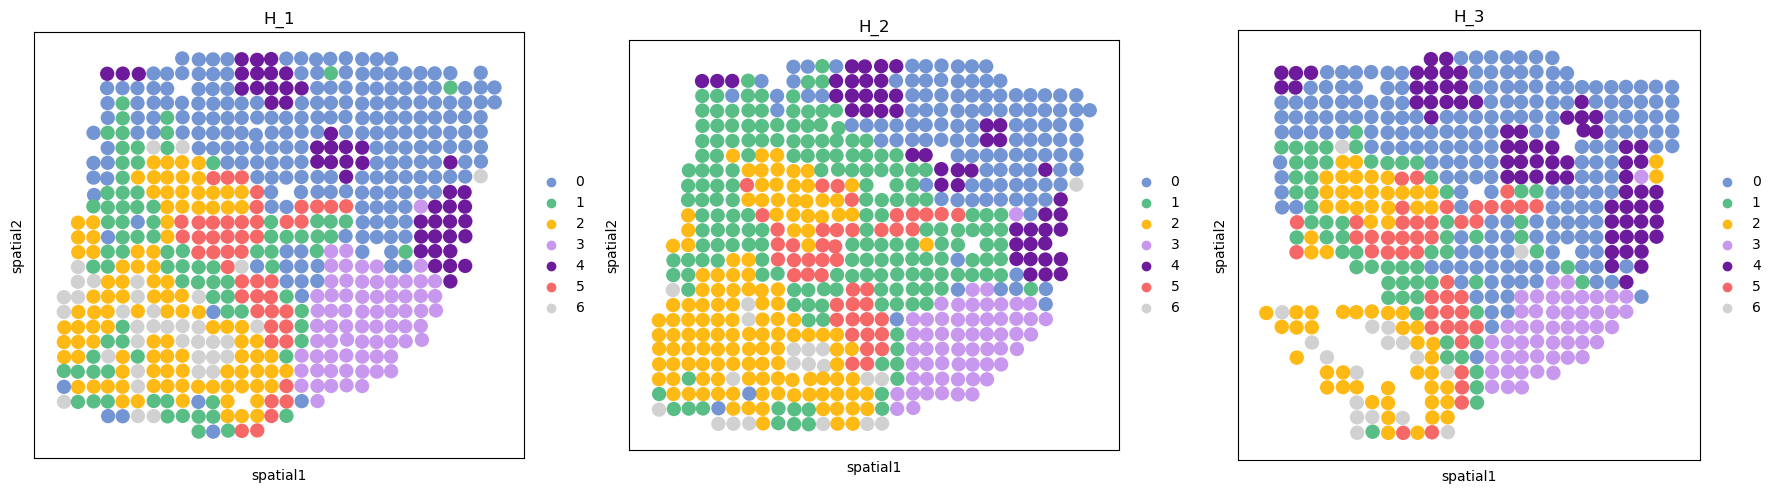

In [15]:
plot_color = ["#7495D3", "#59BE86", "#FEB915", "#C798EE", "#6D1A9C", "#F56867", "#D1D1D1"]
fig, axes = plt.subplots(1, len(SLICE_ORDER), figsize=(18, 5))
for axis, sample in zip(np.atleast_1d(axes), SLICE_ORDER):
    subset = adata[adata.obs["batch_name"] == sample].copy()
    sc.pl.spatial(
        subset, color="louvain", ax=axis, show=False, spot_size=280,
        palette=plot_color, title=sample,
        # legend_loc=None,
    )
plt.tight_layout()
plt.show()

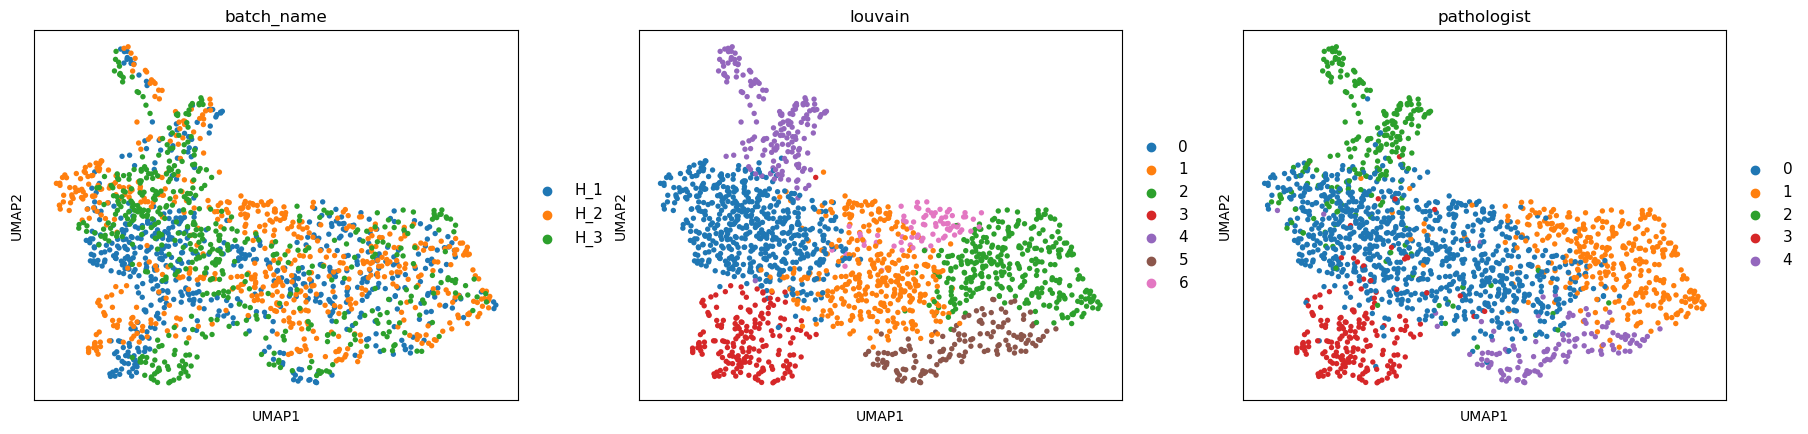

In [16]:
sc.tl.umap(adata, random_state=SEED)
colors = ["batch_name", "louvain"]
if TRUTH_KEY in adata.obs:
    colors.append(TRUTH_KEY)
sc.pl.umap(
    adata, color=colors, size=60,
    legend_fontsize=11, legend_fontoutline=2,
)